# 📦 Amazon Supply Chain Intelligence — EDA

**Objective**: Explore the DataCo Supply Chain dataset to understand patterns, distributions, and relationships that drive delivery delay risk.

**Target**: Engineer and analyze `Delay_Risk_Level` (0=On-Time, 1=At Risk, 2=Delayed)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams.update({
    'figure.facecolor': '#1A2535',
    'axes.facecolor': '#1A2535',
    'axes.edgecolor': '#243045',
    'text.color': '#EAECF0',
    'axes.labelcolor': '#EAECF0',
    'xtick.color': '#8892A4',
    'ytick.color': '#8892A4',
    'grid.color': '#243045',
    'grid.alpha': 0.5,
})
PALETTE = ['#22c55e', '#f59e0b', '#ef4444']
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load Dataset

In [6]:
# Load dataset
df = pd.read_csv('D:\AI_supply_chain_project\DataCoSupplyChainDataset.csv\DataCoSupplyChainDataset.csv', encoding='latin-1')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (180519, 53)
Columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Stat

In [7]:
df.head(3)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [8]:
print('=== DATA TYPES ===')
print(df.dtypes)
print('\n=== BASIC STATS ===')
df.describe().T

=== DATA TYPES ===
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


## 2. Missing Value Analysis

                     Missing Count  Missing %
Product Description         180519     100.00
Order Zipcode               155679      86.24
Customer Lname                   8       0.00
Customer Zipcode                 3       0.00


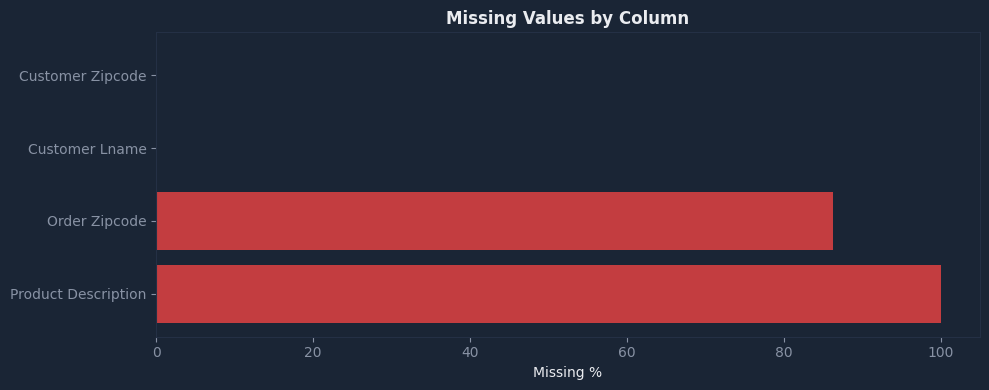

In [9]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(missing_df.index, missing_df['Missing %'], color='#ef4444', alpha=0.8)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Target Variable Engineering

In [10]:
# Engineer Delay_Risk_Level
delay_gap = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

conditions_delayed = (
    (delay_gap > 2) |
    (df['Delivery Status'].isin(['Late delivery', 'Shipping canceled']))
)
conditions_on_time = (delay_gap <= 0) & (df['Late_delivery_risk'] == 0)
conditions_at_risk = (
    ((delay_gap >= 1) & (delay_gap <= 2)) |
    ((df['Late_delivery_risk'] == 1) & (df['Delivery Status'] == 'Shipping on time'))
)

df['Delay_Risk_Level'] = 2
df.loc[conditions_at_risk, 'Delay_Risk_Level'] = 1
df.loc[conditions_on_time, 'Delay_Risk_Level'] = 0
df.loc[conditions_delayed, 'Delay_Risk_Level'] = 2

label_map = {0: 'On-Time', 1: 'At Risk', 2: 'Delayed'}
df['Risk_Label'] = df['Delay_Risk_Level'].map(label_map)

print('Class Distribution:')
print(df['Delay_Risk_Level'].value_counts())

Class Distribution:
Delay_Risk_Level
2    106731
0     73788
Name: count, dtype: int64


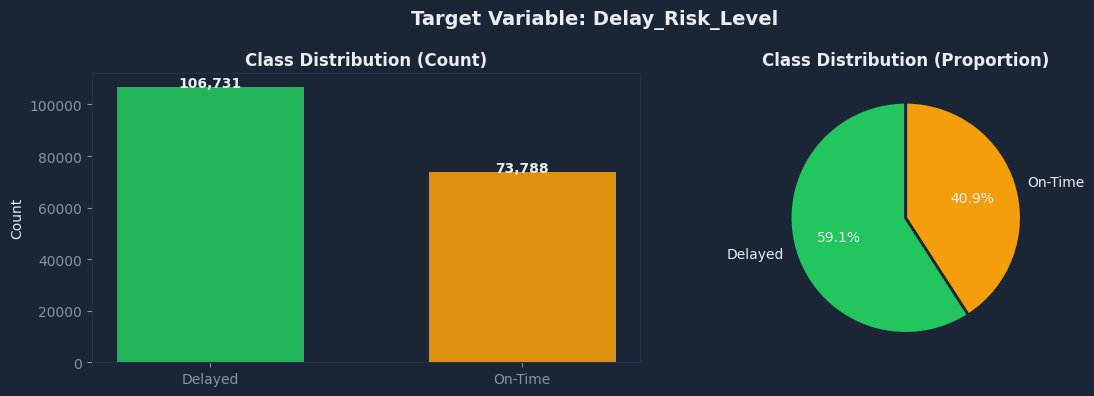

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Risk_Label'].value_counts()
axes[0].bar(counts.index, counts.values, color=PALETTE, alpha=0.9, width=0.6)
axes[0].set_title('Class Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + 200, f'{val:,}', ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, colors=PALETTE, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': '#1A2535', 'linewidth': 2})
axes[1].set_title('Class Distribution (Proportion)', fontweight='bold')
plt.suptitle('Target Variable: Delay_Risk_Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Univariate Analysis

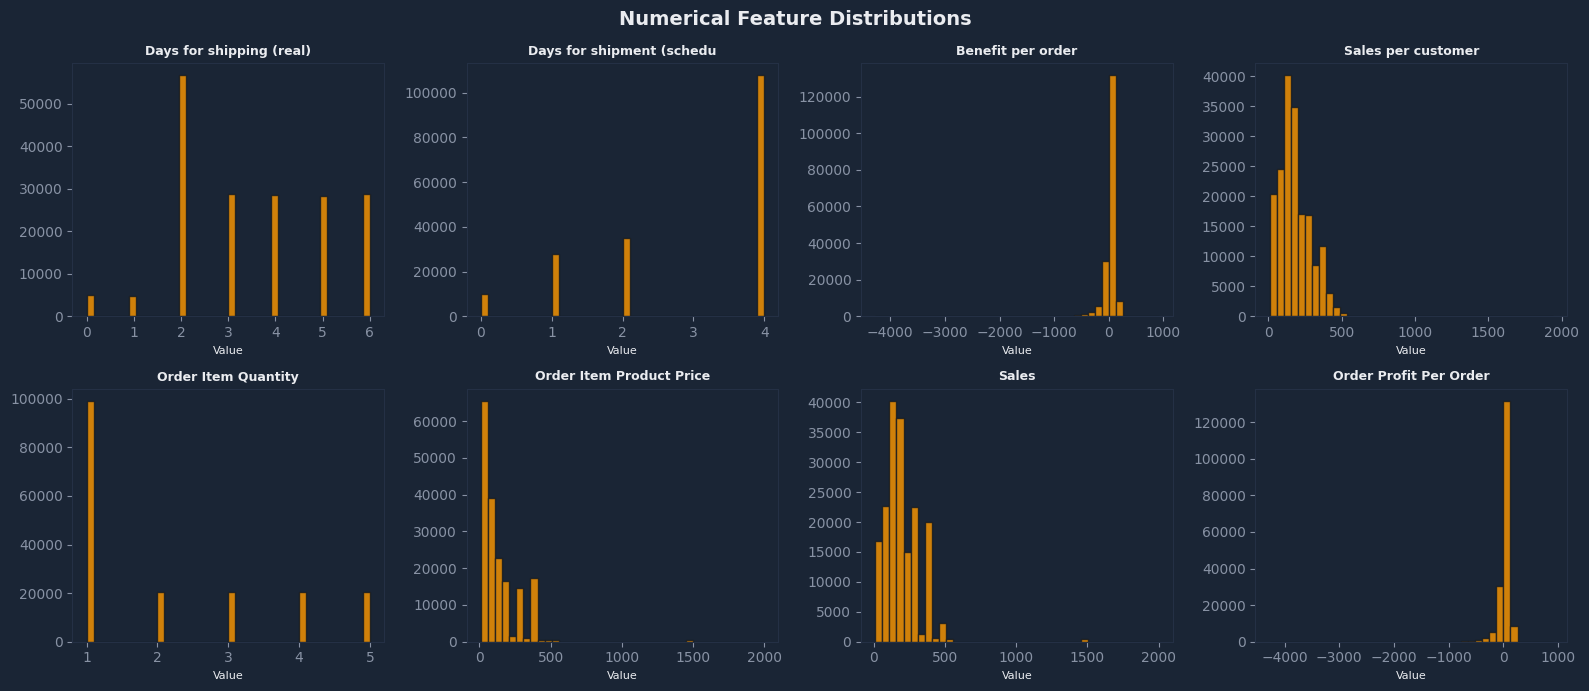

In [12]:
num_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)',
            'Benefit per order', 'Sales per customer', 'Order Item Quantity',
            'Order Item Product Price', 'Sales', 'Order Profit Per Order']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    if col in df.columns:
        axes[i].hist(df[col].dropna(), bins=40, color='#FF9900', alpha=0.8, edgecolor='#131921')
        axes[i].set_title(col[:25], fontsize=9, fontweight='bold')
        axes[i].set_xlabel('Value', fontsize=8)
plt.suptitle('Numerical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

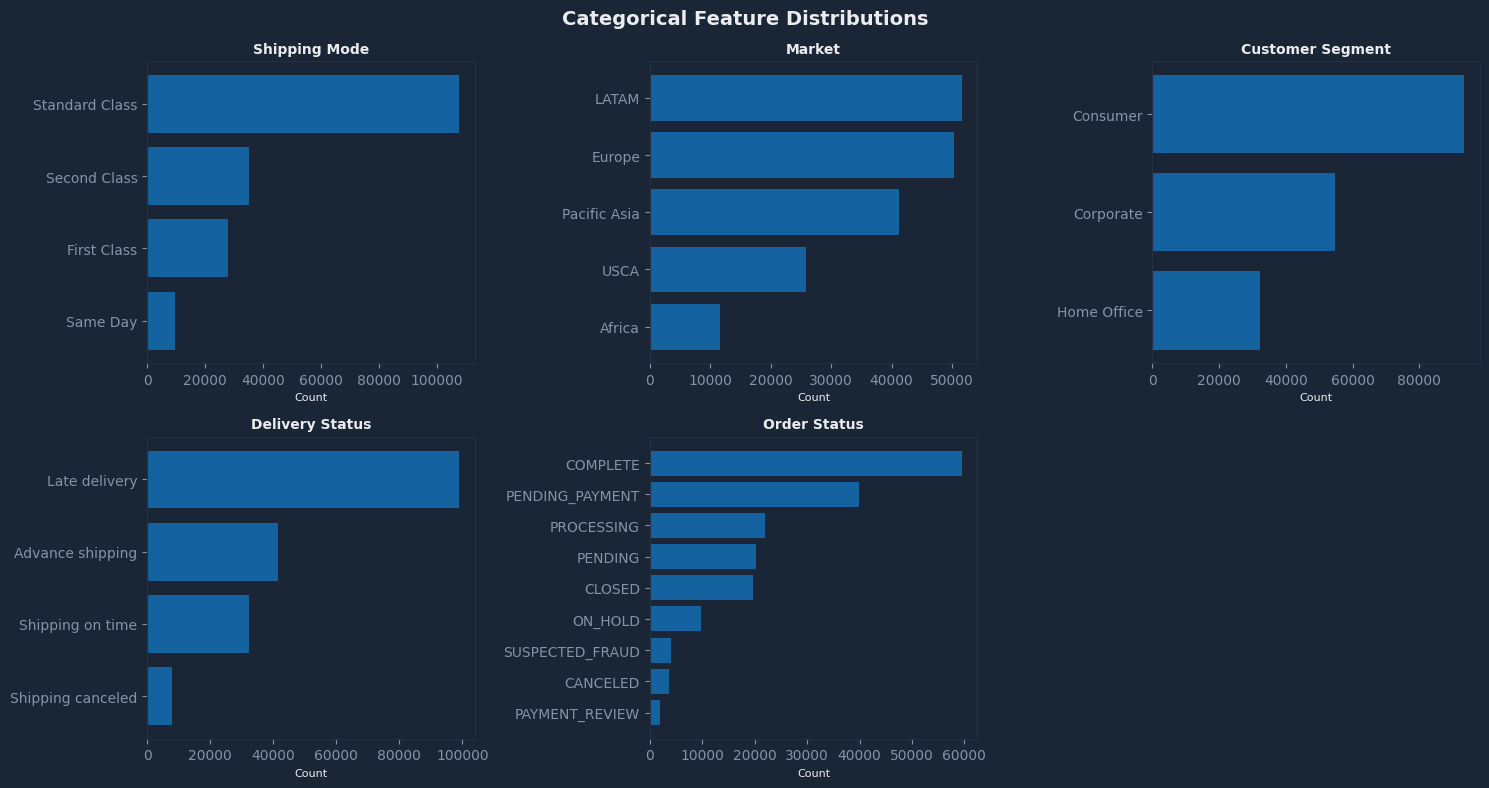

In [13]:
cat_cols = ['Shipping Mode', 'Market', 'Customer Segment', 'Delivery Status', 'Order Status']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if col in df.columns:
        vc = df[col].value_counts().head(10)
        axes[i].barh(vc.index[::-1], vc.values[::-1], color='#146EB4', alpha=0.85)
        axes[i].set_title(col, fontweight='bold', fontsize=10)
        axes[i].set_xlabel('Count', fontsize=8)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Categorical Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Bivariate Analysis

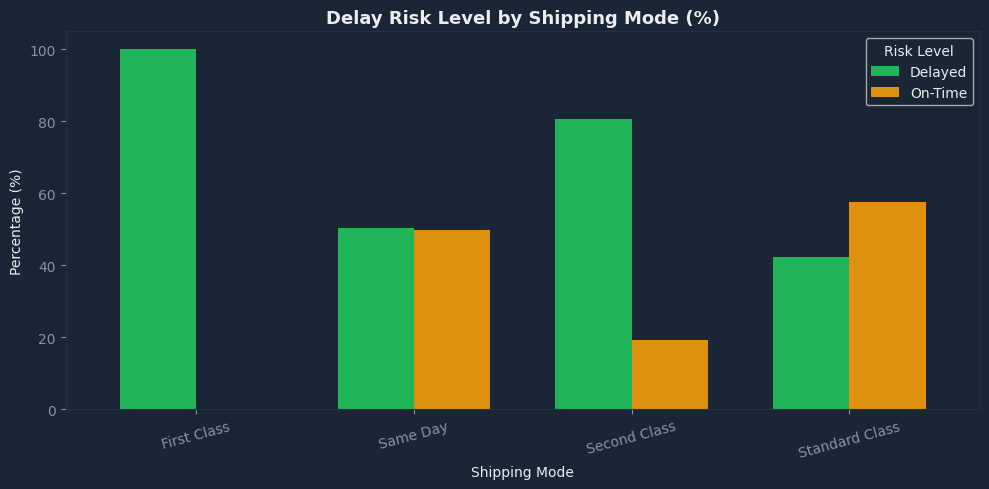

In [14]:
# Delay Risk vs Shipping Mode
if 'Shipping Mode' in df.columns:
    ct = pd.crosstab(df['Shipping Mode'], df['Risk_Label'], normalize='index') * 100
    ct.plot(kind='bar', color=PALETTE, figsize=(10, 5), alpha=0.9, width=0.7)
    plt.title('Delay Risk Level by Shipping Mode (%)', fontweight='bold', fontsize=13)
    plt.xlabel('Shipping Mode'); plt.ylabel('Percentage (%)')
    plt.xticks(rotation=15); plt.legend(title='Risk Level'); plt.tight_layout()
    plt.show()

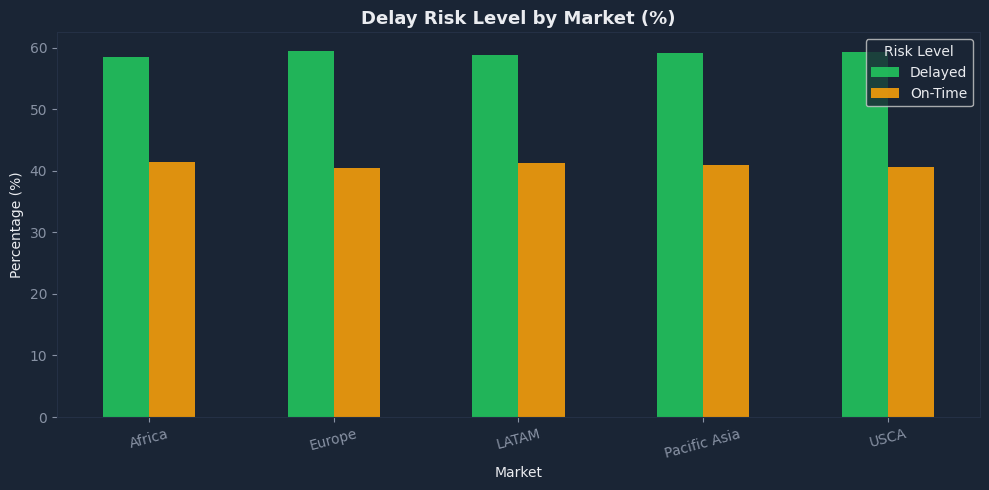

In [15]:
# Delay Risk vs Market
if 'Market' in df.columns:
    ct = pd.crosstab(df['Market'], df['Risk_Label'], normalize='index') * 100
    ct.plot(kind='bar', color=PALETTE, figsize=(10, 5), alpha=0.9)
    plt.title('Delay Risk Level by Market (%)', fontweight='bold', fontsize=13)
    plt.xlabel('Market'); plt.ylabel('Percentage (%)')
    plt.xticks(rotation=15); plt.legend(title='Risk Level'); plt.tight_layout()
    plt.show()

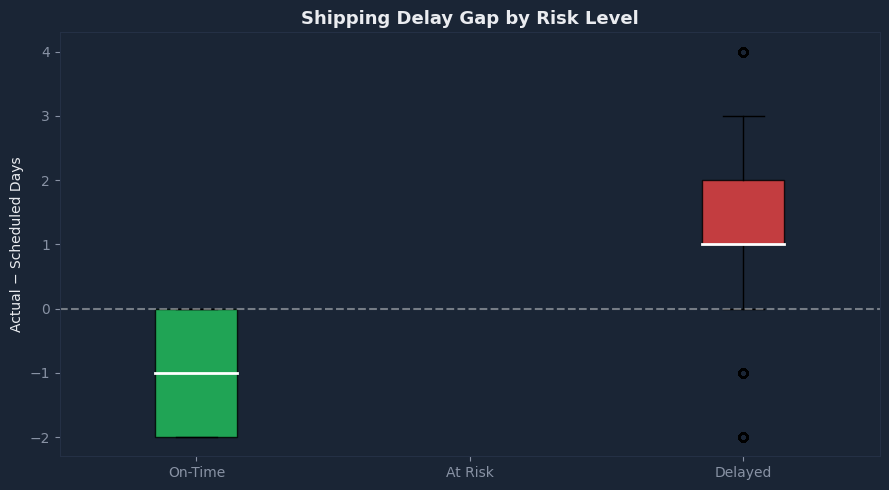

In [16]:
# Box plot: Days gap by risk level
df['delay_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    [df[df['Delay_Risk_Level']==i]['delay_gap'].dropna() for i in [0,1,2]],
    labels=['On-Time', 'At Risk', 'Delayed'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('Shipping Delay Gap by Risk Level', fontweight='bold', fontsize=13)
ax.set_ylabel('Actual − Scheduled Days')
ax.axhline(0, color='white', linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

## 6. Correlation Heatmap

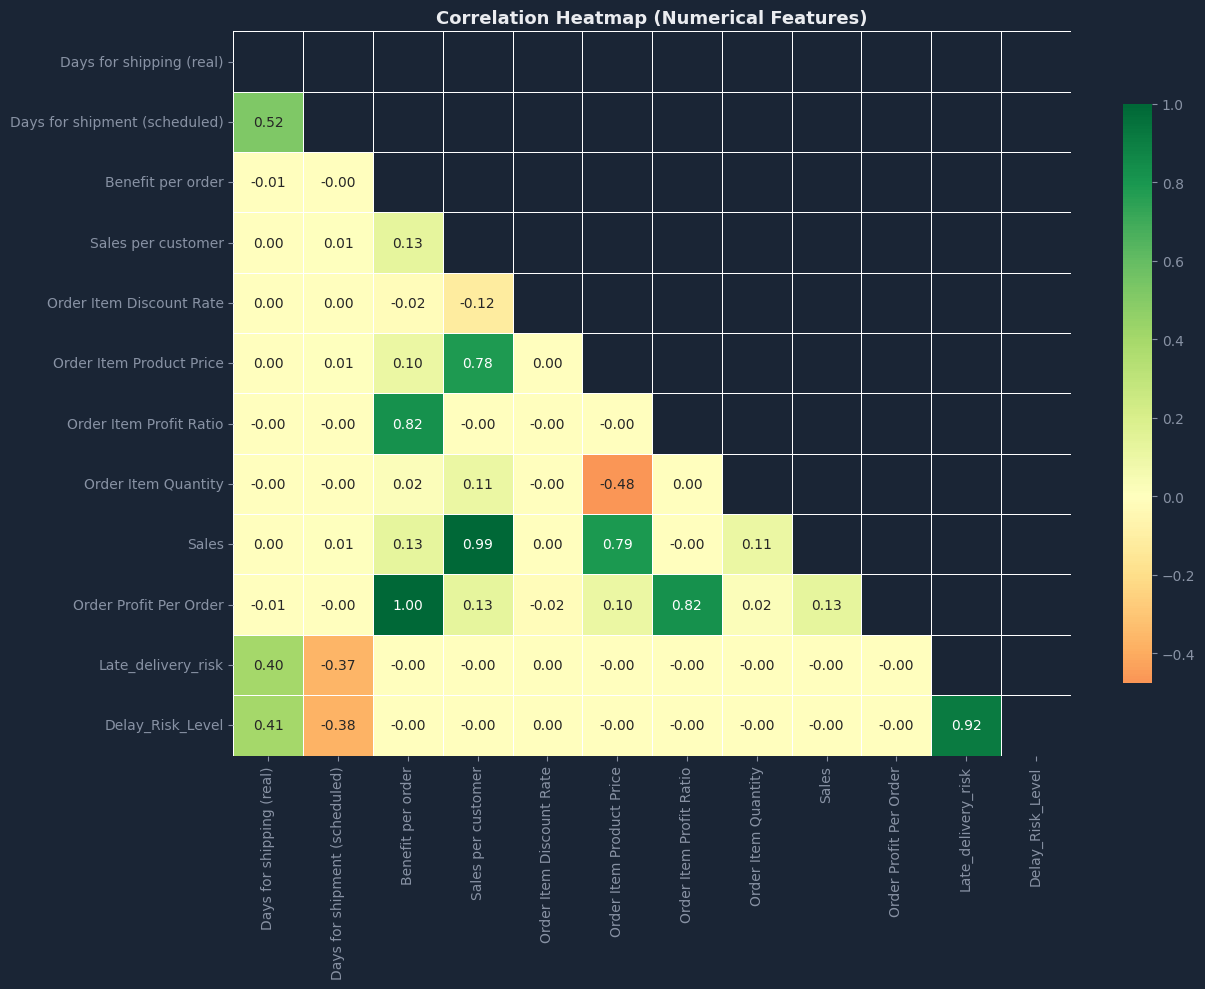

In [17]:
corr_cols = ['Days for shipping (real)', 'Days for shipment (scheduled)',
             'Benefit per order', 'Sales per customer', 'Order Item Discount Rate',
             'Order Item Product Price', 'Order Item Profit Ratio',
             'Order Item Quantity', 'Sales', 'Order Profit Per Order',
             'Late_delivery_risk', 'Delay_Risk_Level']
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Numerical Features)', fontweight='bold', fontsize=13)
plt.tight_layout(); plt.show()

## 7. Outlier Detection

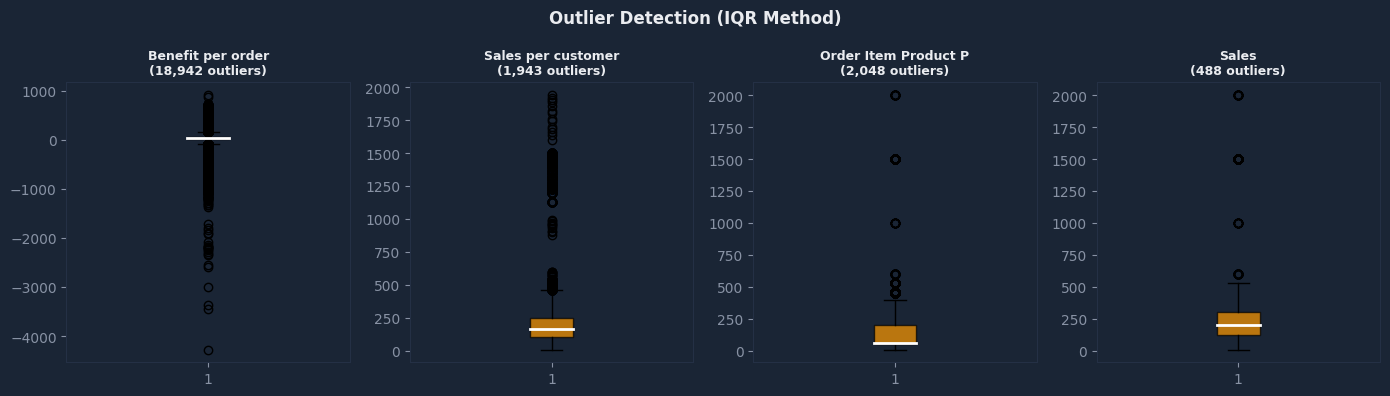

In [18]:
outlier_cols = ['Benefit per order', 'Sales per customer', 'Order Item Product Price', 'Sales']
outlier_cols = [c for c in outlier_cols if c in df.columns]

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(14, 4))
for ax, col in zip(axes if len(outlier_cols) > 1 else [axes], outlier_cols):
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)][col]
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#FF9900', alpha=0.7),
               medianprops=dict(color='white', linewidth=2))
    ax.set_title(f'{col[:20]}\n({len(outliers):,} outliers)', fontsize=9, fontweight='bold')

plt.suptitle('Outlier Detection (IQR Method)', fontweight='bold')
plt.tight_layout(); plt.show()

## 8. Geographic Analysis

In [19]:
if 'Latitude' in df.columns and 'Longitude' in df.columns:
    sample = df.dropna(subset=['Latitude', 'Longitude']).sample(min(5000, len(df)))
    fig = px.scatter(
        sample, x='Longitude', y='Latitude',
        color='Risk_Label',
        color_discrete_map={'On-Time': '#22c55e', 'At Risk': '#f59e0b', 'Delayed': '#ef4444'},
        opacity=0.5, title='Order Locations by Delay Risk Level',
        template='plotly_dark',
    )
    fig.update_traces(marker=dict(size=3))
    fig.show()

## 9. Time-Based Analysis

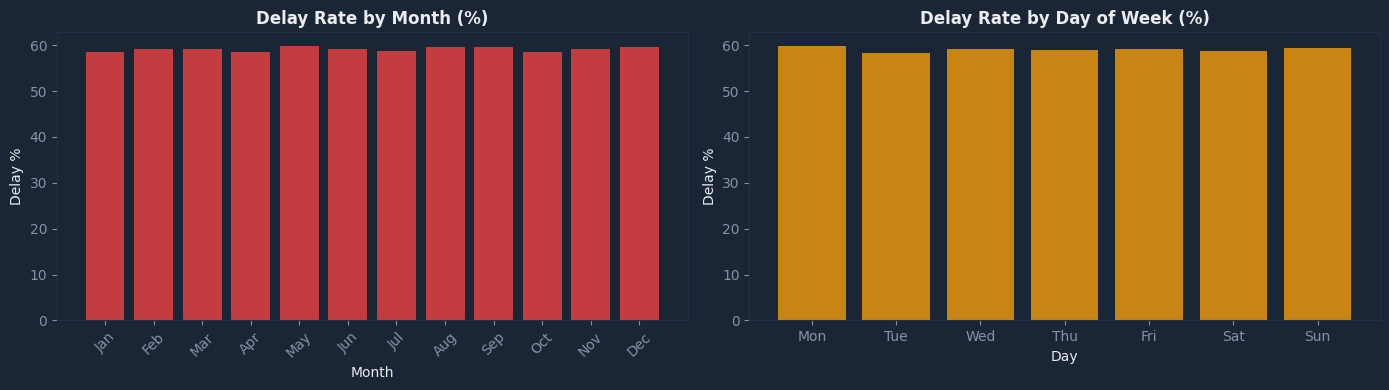

In [20]:
if 'order date (DateOrders)' in df.columns:
    df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], errors='coerce')
    df['order_month'] = df['order_date'].dt.month
    df['order_dow'] = df['order_date'].dt.dayofweek

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Delay rate by month
    monthly = df.groupby('order_month')['Delay_Risk_Level'].apply(lambda x: (x==2).mean() * 100)
    axes[0].bar(monthly.index, monthly.values, color='#ef4444', alpha=0.8)
    axes[0].set_title('Delay Rate by Month (%)', fontweight='bold')
    axes[0].set_xlabel('Month'); axes[0].set_ylabel('Delay %')
    axes[0].set_xticks(range(1, 13))
    axes[0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)

    # Delay rate by day of week
    dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
    daily = df.groupby('order_dow')['Delay_Risk_Level'].apply(lambda x: (x==2).mean() * 100)
    axes[1].bar(daily.index, daily.values, color='#f59e0b', alpha=0.8)
    axes[1].set_title('Delay Rate by Day of Week (%)', fontweight='bold')
    axes[1].set_xlabel('Day'); axes[1].set_ylabel('Delay %')
    axes[1].set_xticks(range(7))
    axes[1].set_xticklabels(dow_labels)

    plt.tight_layout(); plt.show()

## 10. Feature Engineering Preview

In [21]:
# Preview engineered features
df['shipping_delay_gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
df['discount_impact'] = df.get('Order Item Discount', 0) / (df.get('Order Item Product Price', 1) + 1)
df['profit_margin'] = df.get('Order Profit Per Order', 0) / (df.get('Sales', 1) + 1)

new_feats = ['shipping_delay_gap', 'discount_impact', 'profit_margin']
print('Engineered Feature Stats:')
df[new_feats].describe()

Engineered Feature Stats:


,shipping_delay_gap,discount_impact,profit_margin
count,180519.000000,180519.000000,180519.000000
mean,0.565807,0.212006,0.107465
std,1.490966,0.229252,0.417319
min,-2.000000,0.000000,-2.744505
25%,0.000000,0.054584,0.061746
50%,1.000000,0.147059,0.240482
75%,1.000000,0.251654,0.333461
max,4.000000,1.237647,0.499012


## 11. Class Imbalance Visualization

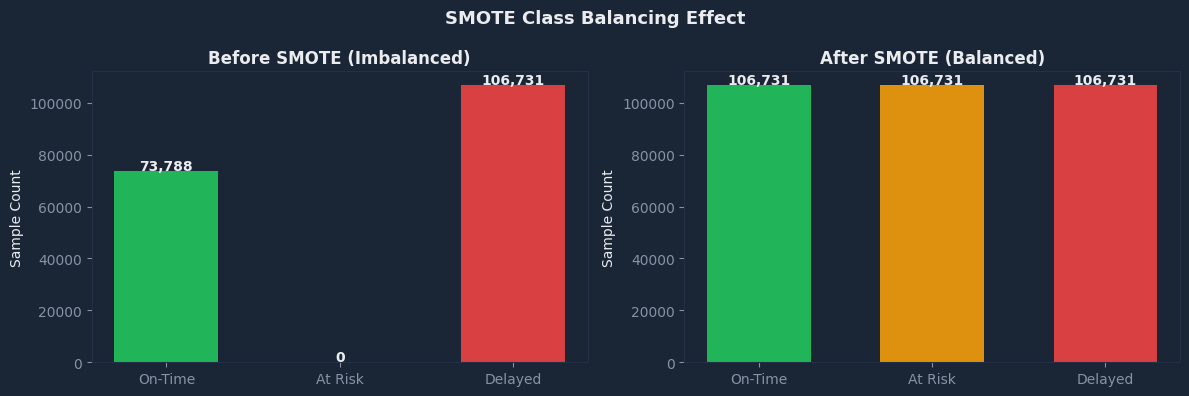

In [25]:
from imblearn.over_sampling import SMOTE
import numpy as np

class_counts = df['Delay_Risk_Level'].value_counts().sort_index().reindex([0, 1, 2], fill_value=0)
balanced_counts = np.array([class_counts.max()] * 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['On-Time', 'At Risk', 'Delayed']

axes[0].bar(labels, class_counts.values, color=PALETTE, alpha=0.9, width=0.6)
axes[0].set_title('Before SMOTE (Imbalanced)', fontweight='bold')
axes[0].set_ylabel('Sample Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(labels, balanced_counts, color=PALETTE, alpha=0.9, width=0.6)
axes[1].set_title('After SMOTE (Balanced)', fontweight='bold')
axes[1].set_ylabel('Sample Count')
for i, v in enumerate(balanced_counts):
    axes[1].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('SMOTE Class Balancing Effect', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Key Insights Summary

### 🔑 Key EDA Findings

1. **Class Imbalance**: The dataset has significant imbalance across On-Time / At Risk / Delayed classes — SMOTE is essential.

2. **Shipping Delay Gap**: The computed `shipping_delay_gap` is the single strongest predictor of delay risk. Orders with positive gaps (actual > scheduled) are overwhelmingly delayed.

3. **Shipping Mode**: Standard Class has significantly higher delay rates than Same Day and First Class — mode is a critical feature.

4. **Geographic Variation**: Certain markets (particularly Africa and LATAM) show higher systematic delay rates — market and region risk scores will be useful features.

5. **Late Delivery Risk Flag**: The existing `Late_delivery_risk` column is highly correlated with the target — but we must not use it to leak future information.

6. **Outliers**: `Benefit per order` and `Order Profit Per Order` have significant outliers — median imputation is preferred over mean.

7. **Time Patterns**: Weekend orders and certain months show elevated delay rates — temporal features add signal.

8. **Missing Data**: Relatively few missing values; median/mode imputation is sufficient.

In [24]:
df.shape


(180519, 62)